In [1]:
from google.colab import drive
drive.mount('/content/drive') # Allows access to the dataset stored in Drive

Mounted at /content/drive


In [2]:
# ============================================================
# Import Required Libraries
# ============================================================
# Import pandas for data manipulation and analysis
import pandas as pd
# Import numpy for numerical computations
import numpy as np
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt
# Import seaborn for attractive statistical visualizations
import seaborn as sns
# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
# Display plots inside Jupyter Notebook
%matplotlib inline

In [3]:
# ============================================================
# Load Dataset
# ============================================================
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("/content/Solar/Solar Power Plant Data.csv")
# Display the first five rows of the dataset
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [4]:
# Display shape of dataset
df.shape

(8760, 8)

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [6]:
# Display statistical summary
df.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


In [7]:
# Check whether any missing values exist
df.isnull().sum()

,0
Date-Hour(NMT),0
WindSpeed,0
Sunshine,0
AirPressure,0
Radiation,0
AirTemperature,0
RelativeAirHumidity,0
SystemProduction,0


In [8]:
# Count duplicate rows
duplicates = df.duplicated().sum()
# Print duplicate count
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [9]:
# Print all column names
print(df.columns)

Index(['Date-Hour(NMT)', 'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation',
       'AirTemperature', 'RelativeAirHumidity', 'SystemProduction'],
      dtype='object')


In [10]:
# Display five random records
df.sample(5)

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
4863,22.07.2017-15:00,3.1,60,1018.9,707.1,23.9,38,6062.3334
390,17.01.2017-06:00,0.8,0,1029.5,-5.6,-4.0,90,0.0000
6804,11.10.2017-12:00,1.2,0,1003.1,92.7,5.1,94,373.3334
6769,10.10.2017-01:00,1.5,0,1013.1,-8.1,2.3,84,0.0000
909,07.02.2017-21:00,4.8,0,1043.4,-5.0,-6.5,72,0.0000


In [13]:
# Display all column names
print(df.columns)
# Convert 'Date-Hour(NMT)' column into datetime format
# Dataset format: Day.Month.Year-Hour:Minute (e.g., 01.01.2020-00:00)
df['Date-Hour(NMT)'] = pd.to_datetime(
    df['Date-Hour(NMT)'],
    format='%d.%m.%Y-%H:%M'
)
# Display first five rows to verify conversion
df.head()

Index(['Date-Hour(NMT)', 'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation',
       'AirTemperature', 'RelativeAirHumidity', 'SystemProduction'],
      dtype='object')


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [14]:
# ============================================================
# Feature Engineering
# Extract useful information from Date
# ============================================================
# Extract Hour
df['Hour'] = df['Date-Hour(NMT)'].dt.hour
# Extract Day
df['Day'] = df['Date-Hour(NMT)'].dt.day
# Extract Month
df['Month'] = df['Date-Hour(NMT)'].dt.month
# Extract Year
df['Year'] = df['Date-Hour(NMT)'].dt.year
# Extract Day of Week
# Monday=0 Sunday=6
df['DayOfWeek'] = df['Date-Hour(NMT)'].dt.dayofweek
# Display first rows
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Day,Month,Year,DayOfWeek
0,2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,0,1,1,2017,6
1,2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,2017,6
2,2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,2,1,1,2017,6
3,2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,3,1,1,2017,6
4,2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0,4,1,1,2017,6


In [15]:
# ============================================================
# Verify Data Types
# ============================================================
# Print information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date-Hour(NMT)       8760 non-null   datetime64[ns]
 1   WindSpeed            8760 non-null   float64       
 2   Sunshine             8760 non-null   int64         
 3   AirPressure          8760 non-null   float64       
 4   Radiation            8760 non-null   float64       
 5   AirTemperature       8760 non-null   float64       
 6   RelativeAirHumidity  8760 non-null   int64         
 7   SystemProduction     8760 non-null   float64       
 8   Hour                 8760 non-null   int32         
 9   Day                  8760 non-null   int32         
 10  Month                8760 non-null   int32         
 11  Year                 8760 non-null   int32         
 12  DayOfWeek            8760 non-null   int32         
dtypes: datetime64[ns](1), float64(5),

In [16]:
# Drop the original date column
df.drop('Date-Hour(NMT)', axis=1, inplace=True)
# Display first rows
df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Day,Month,Year,DayOfWeek
0,0.6,0,1003.8,-7.4,0.1,97,0.0,0,1,1,2017,6
1,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,2017,6
2,0.6,0,1003.4,-6.7,-1.2,99,0.0,2,1,1,2017,6
3,2.4,0,1003.3,-7.2,-1.3,99,0.0,3,1,1,2017,6
4,4.0,0,1003.1,-6.3,3.6,67,0.0,4,1,1,2017,6


In [17]:
# Display missing values
print(df.isnull().sum())

WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
Hour                   0
Day                    0
Month                  0
Year                   0
DayOfWeek              0
dtype: int64


In [19]:
# ============================================================
# Dataset Shape After Cleaning
# ============================================================
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 8760
Columns : 12


In [20]:
# Display random records
df.sample(10)

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Day,Month,Year,DayOfWeek
2750,4.8,16,999.5,414.2,6.2,54,4696.5001,14,25,4,2017,1
1752,2.9,0,1004.8,-7.0,3.6,71,0.0000,0,15,3,2017,2
1073,0.7,51,1034.9,30.1,-0.7,78,0.0000,17,14,2,2017,1
5370,3.5,0,1001.7,60.6,17.0,86,1609.8334,18,12,8,2017,5
3760,3.0,1,1006.0,243.8,18.6,49,2761.3334,16,6,6,2017,1
3666,3.6,0,1019.3,199.5,10.4,72,1332.0000,18,2,6,2017,4
5216,1.2,0,1004.4,43.6,13.7,100,447.0000,8,6,8,2017,6
4509,2.8,0,1010.4,10.9,15.4,83,270.5000,21,7,7,2017,4
6395,3.2,0,1030.7,96.4,14.1,85,731.6666,11,24,9,2017,6
4830,2.1,33,1013.2,153.3,17.2,61,185.0000,6,21,7,2017,4


In [21]:
# Calculate correlation
correlation = df.corr(numeric_only=True)
# Display correlation values
correlation

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Day,Month,Year,DayOfWeek
WindSpeed,1.000000,0.123627,-0.028988,0.191142,0.191490,-0.340053,0.195650,8.359692e-02,3.479126e-02,2.408371e-02,NaN,-3.831571e-02
Sunshine,0.123627,1.000000,0.064096,0.776288,0.376184,-0.613761,0.564228,1.080170e-01,-2.361474e-03,-4.103611e-02,NaN,8.833724e-03
AirPressure,-0.028988,0.064096,1.000000,0.054565,-0.028731,-0.111853,-0.004487,-1.296946e-02,-6.851861e-03,-2.668546e-01,NaN,-5.145596e-02
Radiation,0.191142,0.776288,0.054565,1.000000,0.535159,-0.627944,0.785717,1.041667e-01,1.721214e-02,-6.266375e-02,NaN,-2.092570e-03
AirTemperature,0.191490,0.376184,-0.028731,0.535159,1.000000,-0.389777,0.480407,1.201327e-01,4.833528e-02,1.628389e-01,NaN,1.898761e-02
RelativeAirHumidity,-0.340053,-0.613761,-0.111853,-0.627944,-0.389777,1.000000,-0.545252,-1.715701e-01,-3.015758e-02,9.293024e-02,NaN,7.658945e-03
SystemProduction,0.195650,0.564228,-0.004487,0.785717,0.480407,-0.545252,1.000000,1.606716e-01,2.960773e-02,-3.499034e-02,NaN,5.274489e-03
Hour,0.083597,0.108017,-0.012969,0.104167,0.120133,-0.171570,0.160672,1.000000e+00,1.702457e-16,2.564176e-15,NaN,3.474246e-17
Day,0.034791,-0.002361,-0.006852,0.017212,0.048335,-0.030158,0.029608,1.702457e-16,1.000000e+00,1.189318e-02,NaN,-1.215163e-02
Month,0.024084,-0.041036,-0.266855,-0.062664,0.162839,0.092930,-0.034990,2.564176e-15,1.189318e-02,1.000000e+00,NaN,1.285963e-02


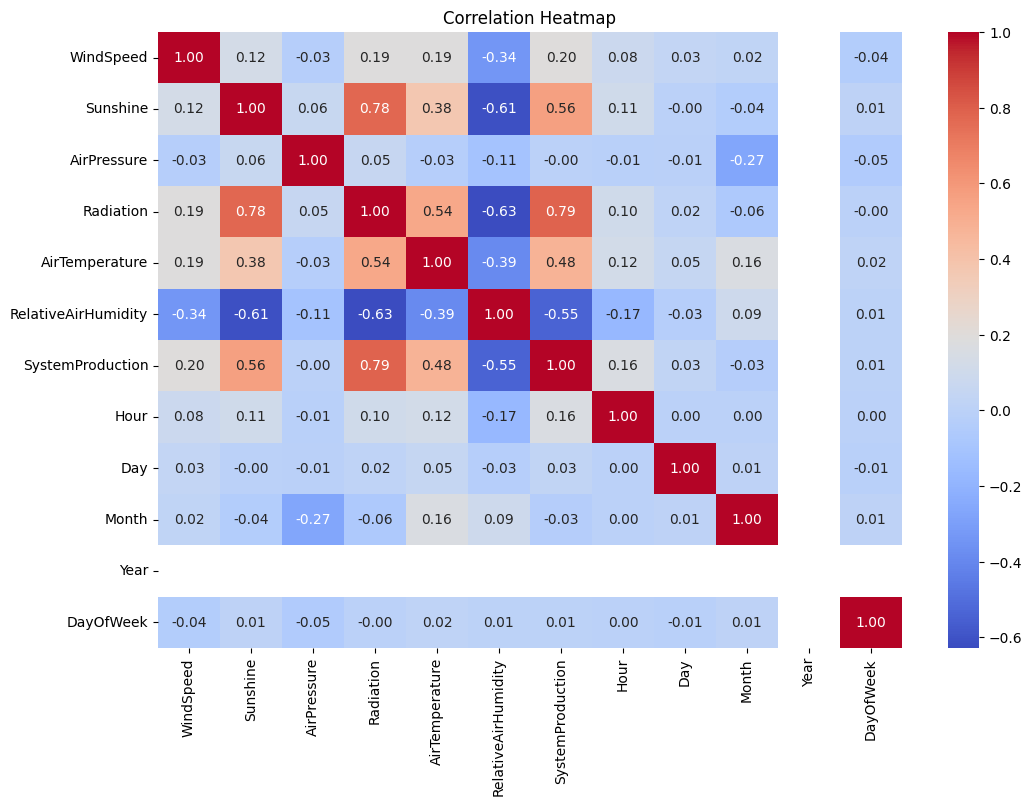

In [22]:
# ============================================================
# Correlation Heatmap
# ============================================================
# Set figure size
plt.figure(figsize=(12,8))
# Draw heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
# Title
plt.title("Correlation Heatmap")
# Show plot
plt.show()

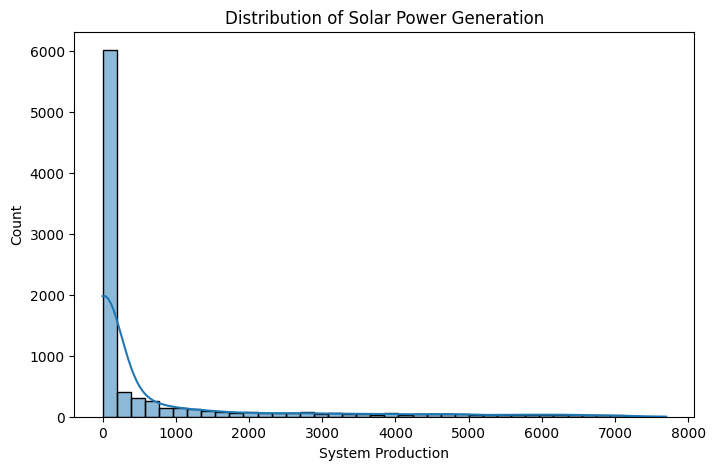

In [23]:
# ============================================================
# Distribution of Target Variable
# ============================================================
# Create figure
plt.figure(figsize=(8,5))
# Plot histogram
sns.histplot(
    df['SystemProduction'],
    bins=40,
    kde=True
)
# Chart title
plt.title("Distribution of Solar Power Generation")
# X label
plt.xlabel("System Production")
# Show graph
plt.show()

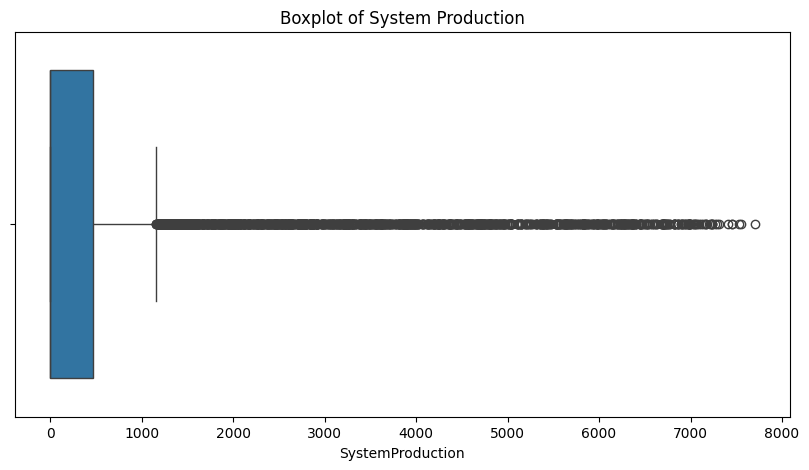

In [24]:
# ============================================================
# Detect Outliers
# ============================================================
plt.figure(figsize=(10,5))
sns.boxplot(
    x=df['SystemProduction']
)
plt.title("Boxplot of System Production")
plt.show()

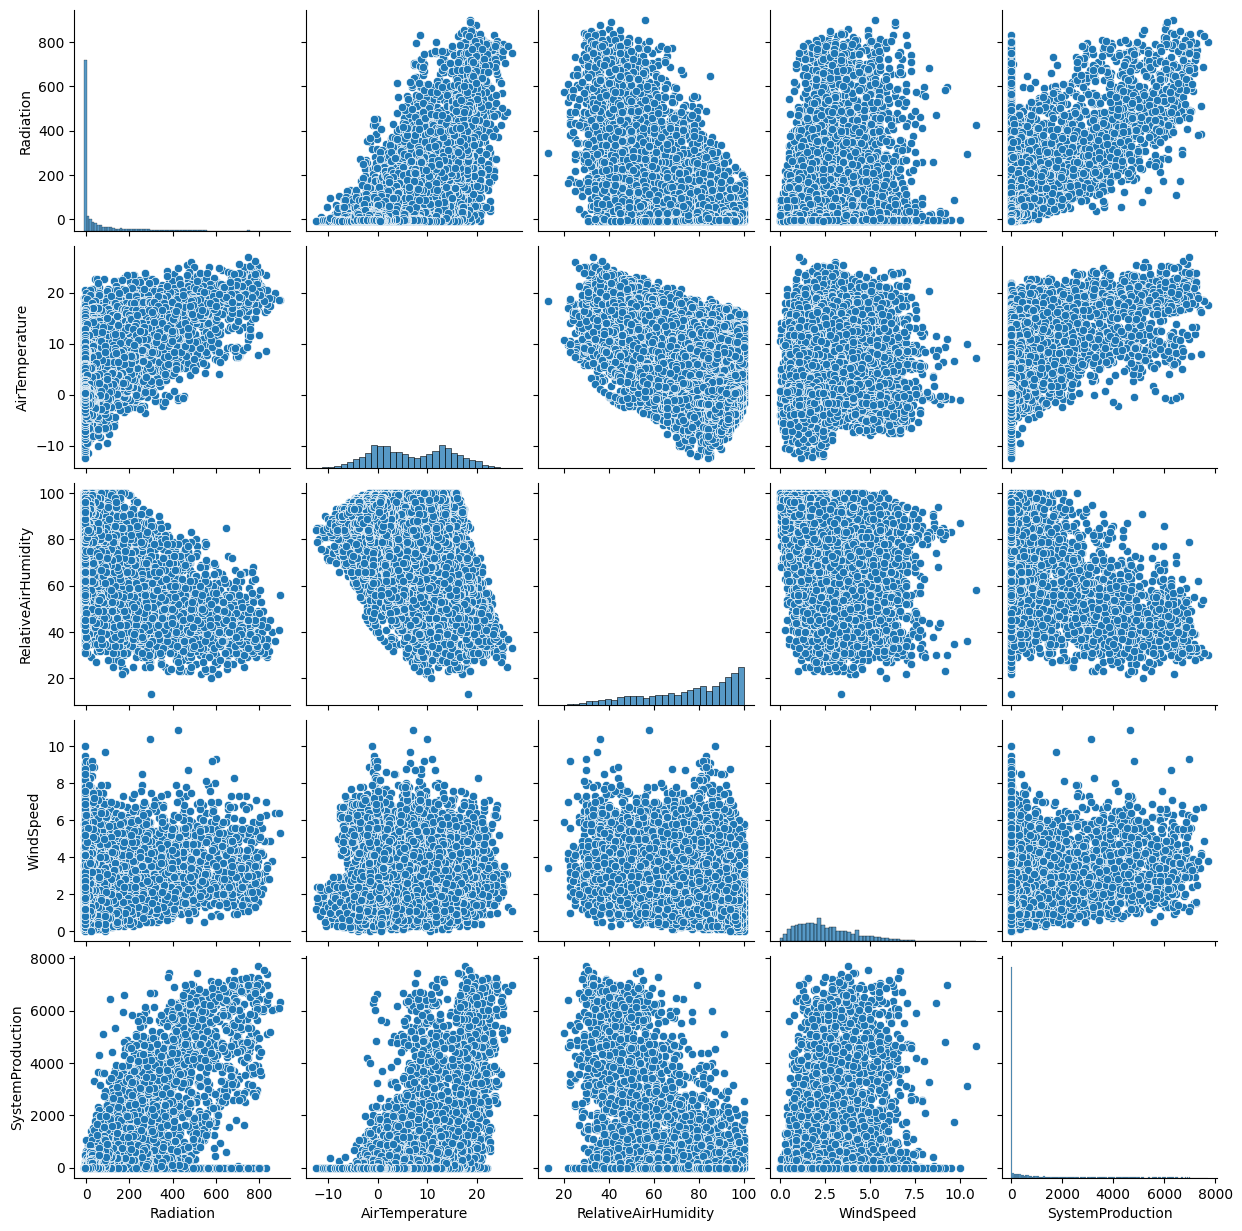

In [25]:
# ============================================================
# Pair Plot
# ============================================================
sns.pairplot(
    df[
        [
            'Radiation',
            'AirTemperature',
            'RelativeAirHumidity',
            'WindSpeed',
            'SystemProduction'
        ]
    ]
)
plt.show()

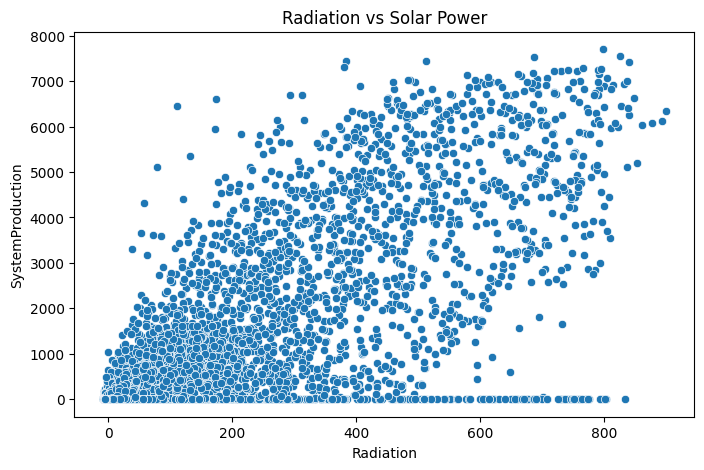

In [26]:
# ============================================================
# Radiation vs Solar Power
# ============================================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Radiation'],
    y=df['SystemProduction']
)
plt.title("Radiation vs Solar Power")
plt.show()

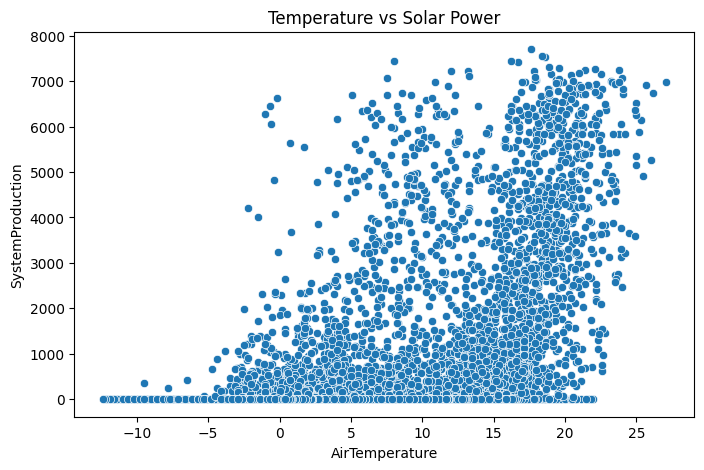

In [27]:
# ============================================================
# Temperature vs Power
# ============================================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['AirTemperature'],
    y=df['SystemProduction']
)
plt.title("Temperature vs Solar Power")
plt.show()

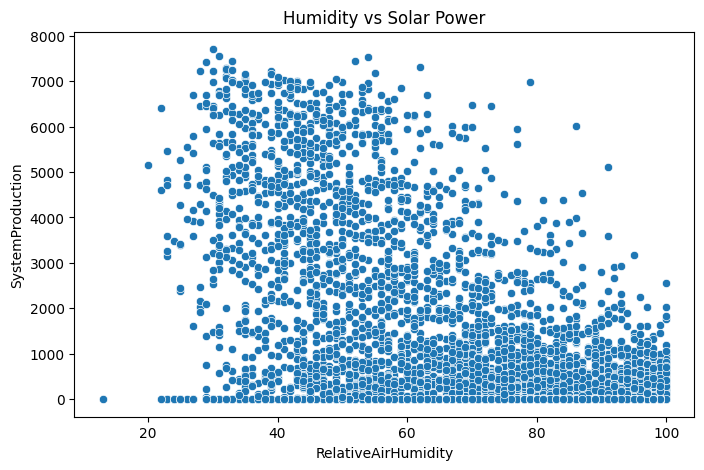

In [28]:
# ============================================================
# Humidity vs Solar Power
# ============================================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['RelativeAirHumidity'],
    y=df['SystemProduction']
)
plt.title("Humidity vs Solar Power")
plt.show()

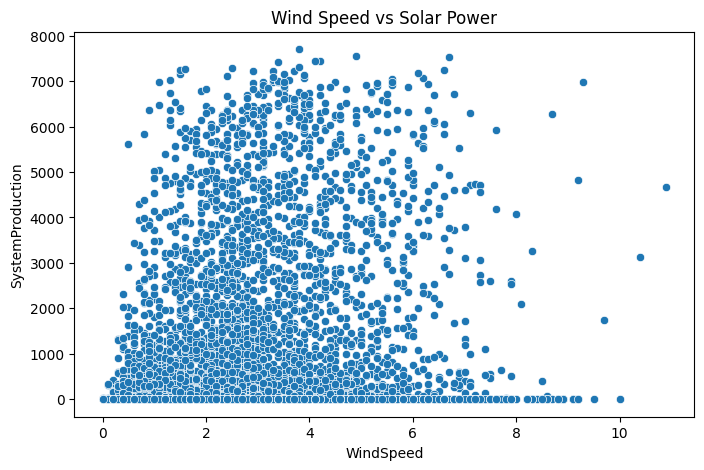

In [29]:
# ============================================================
# Wind Speed vs Solar Power
# ============================================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['WindSpeed'],
    y=df['SystemProduction']
)
plt.title("Wind Speed vs Solar Power")
plt.show()

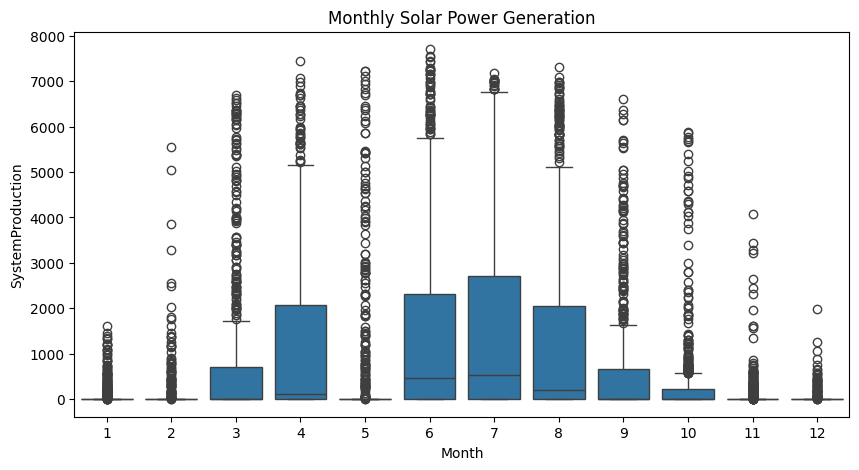

In [30]:
# ============================================================
# Monthly Solar Power
# ============================================================
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Month',
    y='SystemProduction',
    data=df
)
plt.title("Monthly Solar Power Generation")
plt.show()

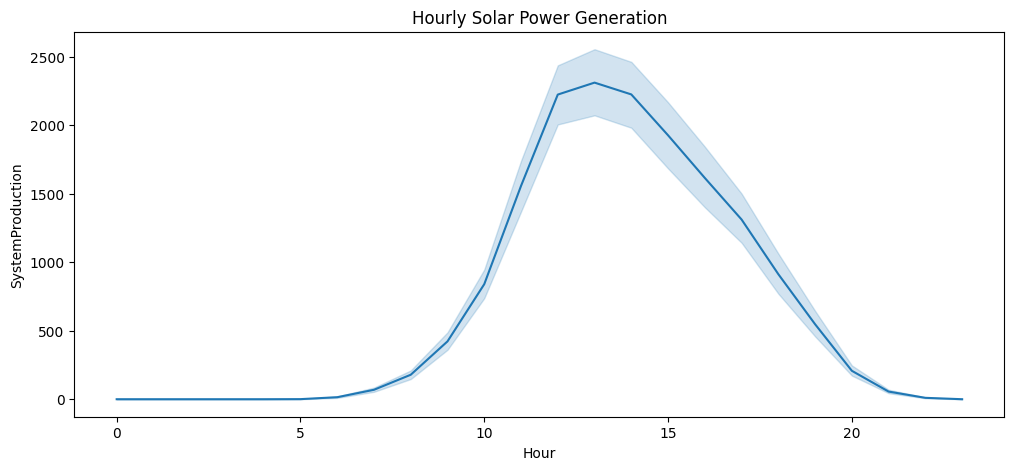

In [31]:
# ============================================================
# Hourly Solar Production
# ============================================================
plt.figure(figsize=(12,5))
sns.lineplot(
    data=df,
    x='Hour',
    y='SystemProduction'
)
plt.title("Hourly Solar Power Generation")
plt.show()

In [32]:
# ============================================================
# Import Machine Learning Libraries
# ============================================================
# Import train-test split function
from sklearn.model_selection import train_test_split
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler
# Import Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
# Uncomment if XGBoost is installed
# from xgboost import XGBRegressor
# Import Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Import Joblib for saving the trained model
import joblib

In [33]:
# ============================================================
# Feature Selection
# ============================================================
# Display all columns
print(df.columns)
# Select input features
X = df[
    [
        'WindSpeed',
        'Sunshine',
        'AirPressure',
        'Radiation',
        'AirTemperature',
        'RelativeAirHumidity',
        'Hour',
        'Day',
        'Month'
    ]
]
# Select target variable
y = df['SystemProduction']
# Display feature matrix shape
print("Feature Shape :", X.shape)
# Display target shape
print("Target Shape :", y.shape)

Index(['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature',
       'RelativeAirHumidity', 'SystemProduction', 'Hour', 'Day', 'Month',
       'Year', 'DayOfWeek'],
      dtype='object')
Feature Shape : (8760, 9)
Target Shape : (8760,)


In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Display shapes
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (7008, 9)
Testing Features : (1752, 9)
Training Labels : (7008,)
Testing Labels : (1752,)


In [35]:
# ============================================================
# Feature Scaling
# ============================================================
# Create StandardScaler object
scaler = StandardScaler()
# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Transform testing data
X_test_scaled = scaler.transform(X_test)
# Display shape
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(7008, 9)
(1752, 9)


In [36]:
# ============================================================
# Linear Regression
# ============================================================
# Create model
lr_model = LinearRegression()
# Train model
lr_model.fit(X_train_scaled, y_train)
# Predict
lr_prediction = lr_model.predict(X_test_scaled)

In [37]:
# ============================================================
# Decision Tree Regressor
# ============================================================
# Create model
dt_model = DecisionTreeRegressor(
    random_state=42
)
# Train model
dt_model.fit(X_train_scaled, y_train)
# Prediction
dt_prediction = dt_model.predict(X_test_scaled)

In [38]:
# ============================================================
# Random Forest Regressor
# ============================================================
# Create model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
# Train model
rf_model.fit(X_train_scaled, y_train)
# Prediction
rf_prediction = rf_model.predict(X_test_scaled)

In [39]:
# ============================================================
# Gradient Boosting Regressor
# ============================================================
# Create model
gb_model = GradientBoostingRegressor(
    random_state=42
)
# Train model
gb_model.fit(X_train_scaled, y_train)
# Prediction
gb_prediction = gb_model.predict(X_test_scaled)

In [41]:
# ============================================================
# XGBoost Regressor
# ============================================================
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
     n_estimators=200,
     learning_rate=0.05,
     max_depth=6,
     random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_prediction = xgb_model.predict(X_test_scaled)

In [43]:
# ============================================================
# Function to Evaluate Regression Models
# ============================================================
def evaluate_model(model_name, y_true, y_pred):
    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Calculate R2 Score
    r2 = r2_score(y_true, y_pred)
    # Print results
    print("="*50)
    print("Model :", model_name)
    print("MAE :", round(mae,3))
    print("RMSE :", round(rmse,3))
    print("R2 Score :", round(r2,3))
    print("="*50)
    # Return metrics
    return mae, rmse, r2

In [44]:
# ============================================================
# Evaluate Models
# ============================================================
lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_prediction
)
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_prediction
)
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_prediction
)
gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_prediction
)
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_prediction
)

Model : Linear Regression
MAE : 472.289
RMSE : 870.796
R2 Score : 0.617
Model : Decision Tree
MAE : 317.308
RMSE : 797.114
R2 Score : 0.679
Model : Random Forest
MAE : 210.49
RMSE : 475.945
R2 Score : 0.886
Model : Gradient Boosting
MAE : 276.306
RMSE : 564.956
R2 Score : 0.839
Model : XGBoost
MAE : 202.192
RMSE : 457.477
R2 Score : 0.894


In [45]:
# ============================================================
# Compare Model Performance
# ============================================================
# Create comparison DataFrame
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE":[
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gb_results[0],
        xgb_results[0]

    ],
    "RMSE":[
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gb_results[1],
        xgb_results[1]

    ],
    "R2 Score":[
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gb_results[2],
        xgb_results[2]
    ]
})
# Sort by R2 Score
results = results.sort_values(
    by="R2 Score",
    ascending=False
)
# Display results
results

,Model,MAE,RMSE,R2 Score
4,XGBoost,202.191771,457.477375,0.894218
2,Random Forest,210.489752,475.944567,0.885505
3,Gradient Boosting,276.305933,564.956153,0.838674
1,Decision Tree,317.308218,797.113619,0.678845
0,Linear Regression,472.289251,870.795840,0.616728


In [46]:
# Display best performing model
print("Best Model")
print(results.iloc[0])

Best Model
Model          XGBoost
MAE         202.191771
RMSE        457.477375
R2 Score      0.894218
Name: 4, dtype: object


In [47]:
# Import joblib
import joblib
# Save the trained XGBoost model
joblib.dump(xgb_model, "model.pkl")
print("model.pkl saved successfully.")

model.pkl saved successfully.


In [48]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")
print("scaler.pkl saved successfully.")

scaler.pkl saved successfully.


               Feature  Importance
3            Radiation    0.529317
6                 Hour    0.166517
8                Month    0.112168
7                  Day    0.073927
5  RelativeAirHumidity    0.032936
4       AirTemperature    0.029900
1             Sunshine    0.022474
2          AirPressure    0.020168
0            WindSpeed    0.012594


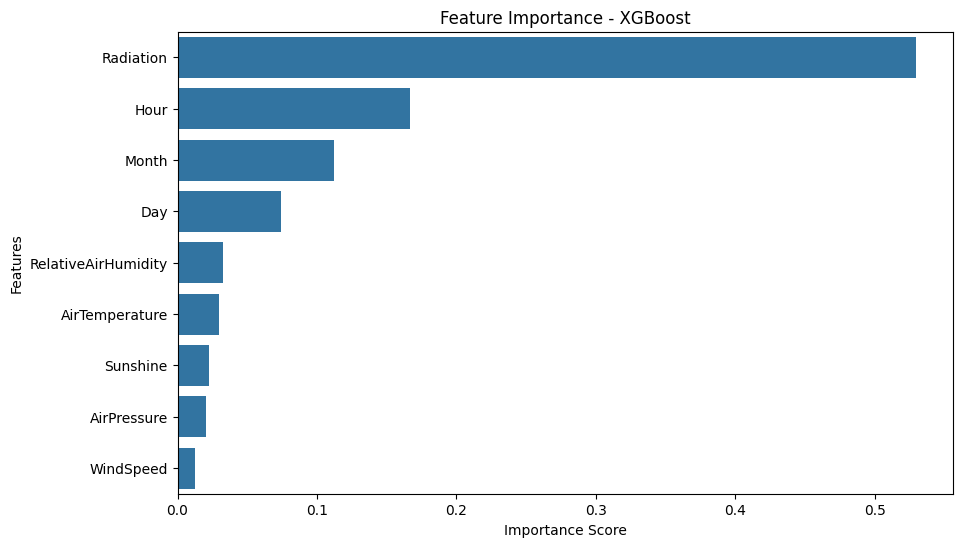

In [49]:
# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})
# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
# Display importance
print(feature_importance)
# Plot graph
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

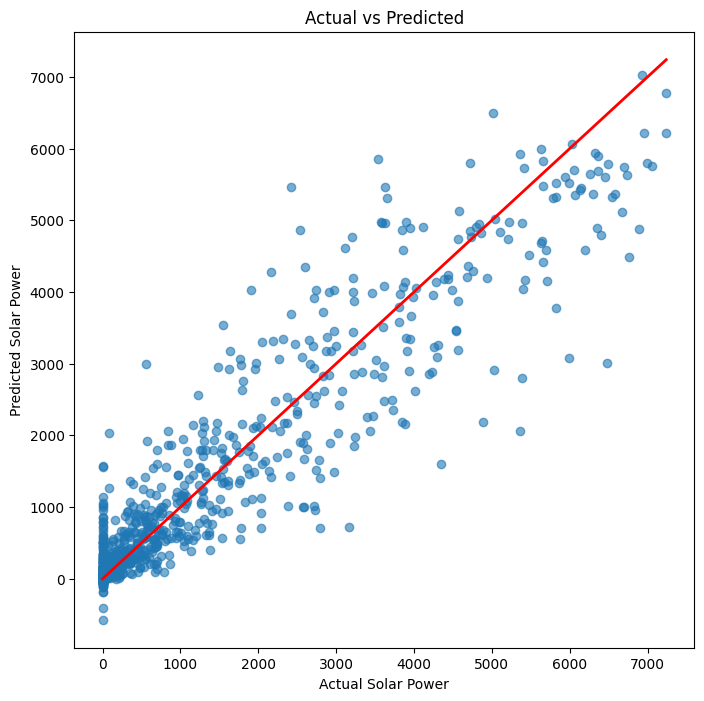

In [50]:
# ============================================================
# Actual vs Predicted Values
# ============================================================
plt.figure(figsize=(8,8))
plt.scatter(
    y_test,
    xgb_prediction,
    alpha=0.6
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual Solar Power")
plt.ylabel("Predicted Solar Power")
plt.title("Actual vs Predicted")
plt.show()

In [51]:
# ============================================================
# Test Prediction
# ============================================================
# Select first testing sample
sample = X_test.iloc[[0]]
# Scale the sample
sample_scaled = scaler.transform(sample)
# Predict
prediction = xgb_model.predict(sample_scaled)
print("Predicted Solar Power :", prediction[0])
print("Actual Solar Power :", y_test.iloc[0])

Predicted Solar Power : 203.5508
Actual Solar Power : 140.1667
